# Тензорный считыватель
```pip install numpy```

Для геолина **меняем местами индексы** *суперстроки* и *суперстолбца*:
```[a][b][c][d][e] -> [a][b][d][c][e]```

В классе Tensor это условие учтено, в остальном - нужно следить **самостоятельно**!

In [14]:
import numpy as np
import itertools as it
from math import *
from enum import Enum

class TStatus(Enum):
    EVEN = 0
    VERTICAL = 1
    HORIZONTAL = 2

class Tensor:
    t: list
    dim: int
    covector: int
    vector: int
    deep: int
    status: TStatus
    
    def __init__(self, s, dim: int, covector: int, vector: int, status: TStatus = None, a_type=int):
        # Check dimensions and indexes
        if covector + vector <= 0:
            raise ValueError('ERR: 0 indexes for vectors or covectors')
            
        # Set dimensions
        self.dim = dim
        self.covector, self.vector = covector, vector
        self.deep = covector + vector
        
        # Check status
        if self.deep % 2:
            if status is not None and status != TStatus.EVEN:
                self.status = status
            else:
                self.status = (TStatus.VERTICAL if self.vector == 0 else TStatus.HORIZONTAL)
        else:
            self.status = TStatus.EVEN
        
        if isinstance(s, str):
            # Clear string data
            s = s.replace('−', '-').replace('\u200b', '').split()
            # Empty t
            self.t = np.zeros([self.dim] * self.deep, a_type)
            
            if self.status is TStatus.HORIZONTAL:
                divisors = [ind // 2 + (self.deep // 2 if ind % 2 else 0) for ind in range(self.deep - 1)] + [self.deep - 1]
            else:
                divisors = [ind // 2 + (self.deep // 2 + self.deep % 2 if ind % 2 else 0) for ind in range(self.deep)]
                
            for m in range(len(s)):
                index = [m // (self.dim ** div) % self.dim for div in divisors]
                self.t[*index] = s[m]
                # print(m + 1, '=', ', '.join(str(x + 1) for x in index), '=', s[m])
        elif isinstance(s, (np.ndarray, np.generic)):
            self.t = s
        else:
            self.t = np.zeros([self.dim] * self.deep, a_type)

    def _iterate_show(self):
        """Переборный интератор для show
        ИНДЕКСАЦИЯ: строка - столбец - суперстрока - суперстолбец - гиперстрока - гиперстолбец -
        """
        axes = list(range(self.deep - 1, -1, -1))
        if self.status is TStatus.HORIZONTAL:
            order = [ax for ax in axes if ax % 2 == 0 and ax != axes[0]] + [axes[0]] + [ax for ax in axes if ax % 2 != 0]
        else:
            order = [ax for ax in axes if ax % 2 == 0] + [ax for ax in axes if ax % 2 != 0]
        # print(axes, order)
        for indices in it.product(range(self.dim), repeat=self.deep):
            original_indices = [0] * self.deep
            for original_axis in range(self.deep):
                pos = order.index(original_axis)
                original_indices[original_axis] = indices[pos]
            yield tuple(original_indices)

    
    def show(self, sym_element=' ', sym_line='\n', sym_superline='\n\n', sym_superraw=' | ') -> str:
        """Превращает тензор в текст для вывода:
            sym_element: между двумя элементами, sym_line: перенос каждую строку,
            sym_superline: перенос каждую суперстроку, sym_superraw: перенос каждый суперстолбец.
        
        ИНДЕКСАЦИЯ: строка - столбец - суперстрока - суперстолбец - гиперстрока - гиперстолбец -
        """
        s = ''
        pre_line, pre_superline, pre_superraw = 0, 0, 0
        for indices in self._iterate_show():
            if len(indices) == 1:
                if (pre_line != indices[0]) and (self.status is TStatus.VERTICAL):
                    s += sym_line
                elif indices[0] != 0:
                    s += sym_element
                pre_line = indices[0]
            elif len(indices) == 2:
                if (pre_line != indices[0]):
                    s += sym_line
                elif indices[0] != 0 or indices[1] != 0:
                    s += sym_element
                pre_line = indices[0]
            elif len(indices) == 3:
                if self.status is TStatus.HORIZONTAL:
                    if (pre_line != indices[0]):
                        s += sym_line
                    elif (pre_superraw != indices[2]):
                        s += sym_superraw
                    elif indices[0] != 0 or indices[1] != 0:
                        s += sym_element
                    pre_line, pre_superraw = indices[0], indices[2]
                else:
                    if (pre_line != indices[0]):
                        s += sym_line
                    elif (pre_superline != indices[2]):
                        s += sym_superline
                    elif indices[0] != 0 or indices[1] != 0:
                        s += sym_element
                    pre_line, pre_superline = indices[0], indices[2]
            else:
                if (pre_line != indices[0]):
                    s += sym_line
                elif (pre_superline != indices[2]):
                        s += sym_superline
                elif (pre_superraw != indices[3]):
                    s += sym_superraw
                elif not all(i == 0 for i in indices):
                    s += sym_element
                pre_line, pre_superline, pre_superraw = indices[0], indices[2], indices[3]
            # print(indices)
            s += str(self.t[indices])
        return s
    
    @property
    def format(self):
        return '[' + self.show(', ', '; ', ', ', ', ') +']'
    
    def __getitem__(self, prop):
        return self.t[prop]
    
    def __setitem__(self, key, value):
        self.t[key] = value
    
    def __str__(self):
        return f'Tensor ({self.vector}, {self.covector}), dim = {self.dim}, status = {self.status}\n' + self.show() + '\n' + self.format
    
    def __repr__(self):
        return f'Tensor ({self.vector}, {self.covector})'
    
    def __mul__(self, other):
        return Tensor(other * self.t, self.dim, self.covector, self.vector, self.status)
    
    def __add__(self, other):
        return Tensor(self.t + other.t, self.dim, self.covector, self.vector, self.status)
    
    def __sub__(self, other):
        return Tensor(self.t - other.t, self.dim, self.covector, self.vector, self.status)
    
    @staticmethod
    def fuck_geolin(indices, COB):
        indices = list(indices)
        if len(indices) <= 3:
            return indices
        if len(COB)==0:
            return indices

        start = 2  # Начало подсписка для обработки
        if len(indices) % 2:
            # Нечётная длина: обрабатываем элементы со 2 до предпоследнего
            sub_len = len(indices) - 3  # Длина подсписка indices[2:-1]
            processed = [indices[start + i + 1] if i % 2 == 0 else indices[start + i - 1] for i in range(sub_len)]
            return indices[:2] + processed + [indices[-1]]
        else:
            # Чётная длина: обрабатываем все элементы с индекса 2
            sub_len = len(indices) - start
            processed = [indices[start + i + 1] if i % 2 == 0 else indices[start + i - 1] for i in range(sub_len)]
            return indices[:2] + processed
    
    def __matmul__(A, B):
        dim = A.dim
        out = Tensor(0, dim, A.covector + B.covector, A.vector + B.vector, a_type=A.t.dtype)
        for COindicesA in it.product(range(dim), repeat=A.covector):
            for COindicesB in it.product(range(dim), repeat=B.covector):
                for indicesA in it.product(range(dim), repeat=A.vector):
                    for indicesB in it.product(range(dim), repeat=B.vector):
                        indices = Tensor.fuck_geolin(COindicesA + COindicesB + indicesA + indicesB, COindicesB)
                        out[*indices] = A[*(COindicesA+indicesA)] * B[*(COindicesB+indicesB)]     
        return out
        
tens = [
    Tensor('1 2', 2, 1, 0),
    Tensor('1 2', 2, 0, 1),
    Tensor('1 2 3 4', 2, 1, 1),
    Tensor('1 2 3 4 5 6 7 8', 2, 3, 0),
    Tensor('1 2 3 4 5 6 7 8', 2, 0, 3),
    Tensor('1 2 3 4 5 6 7 8 9 10 11 12 13 14 15 16', 2, 2, 2),
    Tensor(' '.join(str(x) for x in range(1, 32 + 1)), 2, 5, 0),
    Tensor(' '.join(str(x) for x in range(1, 32 + 1)), 2, 3, 2)
]
# [print('========== ', ten.status, '\n', ten, sep='') for ten in tens[:]]
    

# Задачи

### Задача 2

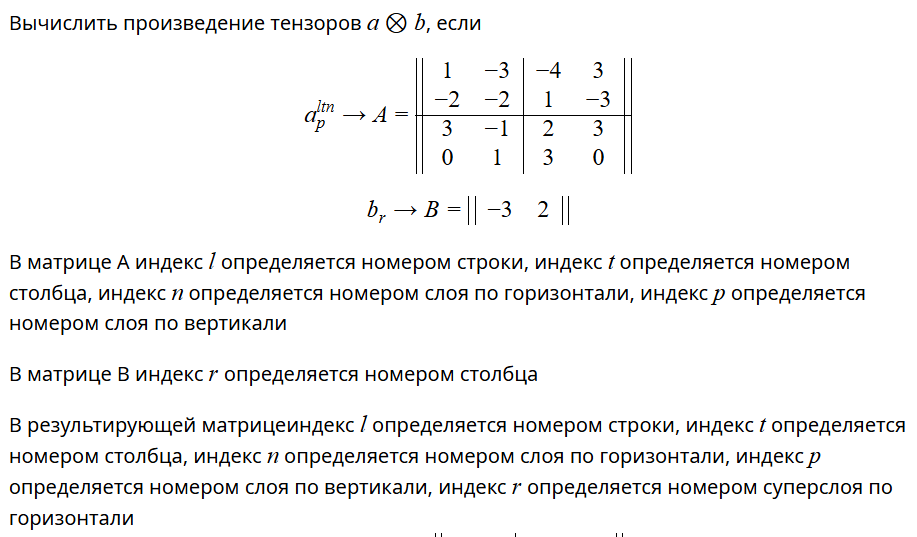

In [15]:
# p строка, k столбец, t суперстолбец
tensor2A = Tensor('1 −2 3 0 ​ −3 −2 −1 1 ​ −4 1 2 3 ​ 3 −3 3 0 ​ ​ ​', 2, 3, 1)
# j строка, r столбец
tensor2B = Tensor('-3 2', 2, 0, 1)
print('A', tensor2A)
print('B', tensor2B)
res = tensor2A @ tensor2B
print('RES', res)

A Tensor (1, 3), dim = 2, status = TStatus.EVEN
1 -3 | -4 3
-2 -2 | 1 -3
3 -1 | 2 3
0 1 | 3 0
[1, -3, -4, 3; -2, -2, 1, -3; 3, -1, 2, 3; 0, 1, 3, 0]
B Tensor (1, 0), dim = 2, status = TStatus.HORIZONTAL
-3 2
[-3, 2]
RES Tensor (2, 3), dim = 2, status = TStatus.HORIZONTAL
-3 9 | 12 -9 | 2 -6 | -8 6
6 6 | -3 9 | -4 -4 | 2 -6
-9 3 | -6 -9 | 6 -2 | 4 6
0 -3 | -9 0 | 0 2 | 6 0
[-3, 9, 12, -9, 2, -6, -8, 6; 6, 6, -3, 9, -4, -4, 2, -6; -9, 3, -6, -9, 6, -2, 4, 6; 0, -3, -9, 0, 0, 2, 6, 0]


### Задача 3

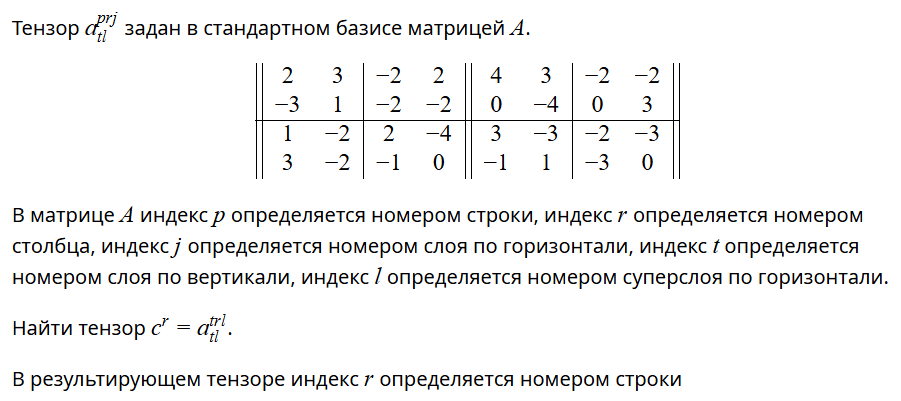

Для геолина **меняем местами индексы** *суперстроки* и *суперстолбца*

In [16]:
data = '''
2 −3 1 3 ​ 3 1 −2 −2 ​ −2 −2 2 −1 ​ 2 −2 −4 0 ​ 4 0 3 −1 ​ 3 −4 −3 1 ​ −2 0 −2 −3 ​ −2 3 −3 0 ​ ​ ​
'''
A = Tensor(data, 2, 3, 2)
print(A)
C = Tensor(0, 2, 1, 0)

for r, t, l in it.product(range(2), repeat=3):
    # swap СУПЕРСТРОКА - СУПЕРСТОЛБЕЦ
    C[r] += A[t][r][t][l][l]
                
print(C)

Tensor (2, 3), dim = 2, status = TStatus.HORIZONTAL
2 3 | -2 2 | 4 3 | -2 -2
-3 1 | -2 -2 | 0 -4 | 0 3
1 -2 | 2 -4 | 3 -3 | -2 -3
3 -2 | -1 0 | -1 1 | -3 0
[2, 3, -2, 2, 4, 3, -2, -2; -3, 1, -2, -2, 0, -4, 0, 3; 1, -2, 2, -4, 3, -3, -2, -3; 3, -2, -1, 0, -1, 1, -3, 0]
Tensor (0, 1), dim = 2, status = TStatus.VERTICAL
0
-1
[0; -1]


### Задача 4

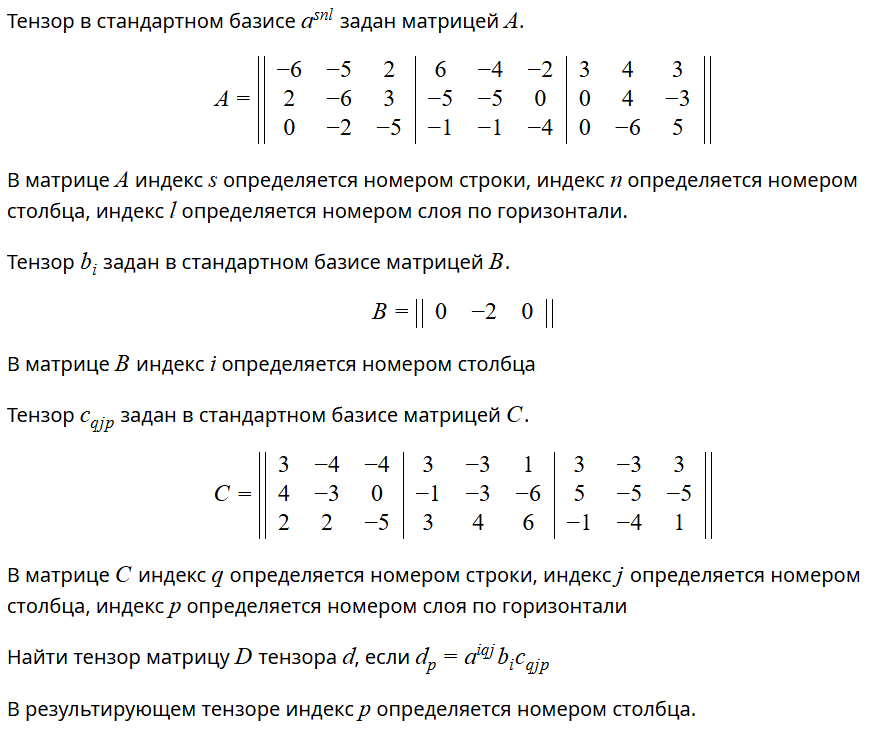

Не забываем про количество **for** для переменных!

Не забываем про **гориз/верт** расположение тензора D: `TStatus`

In [23]:
dataA = "−6 2 0 ​ −5 −6 −2 ​ 2 3 −5 ​ 6 −5 −1 ​ −4 −5 −1 ​ −2 0 −4 ​ 3 0 0 ​ 4 4 −6 ​ 3 −3 5 ​ ​"
dataB = "0 ​ −2 ​ 0 ​"
dataC = "3 4 2 ​ −4 −3 2 ​ −4 0 −5 ​ 3 −1 3 ​ −3 −3 4 ​ 1 −6 6 ​ 3 5 −1 ​ −3 −5 −4 ​ 3 −5 1 ​ ​"

A = Tensor(dataA, 3, 3, 0, TStatus.HORIZONTAL)
B = Tensor(dataB, 3, 0, 1, TStatus.HORIZONTAL)
C = Tensor(dataC, 3, 0, 3, TStatus.HORIZONTAL)
# print(A, B, C, sep='\n')

D = Tensor(0, 3, 0, 1)
for i, j, q, p in it.product(range(3), repeat=4):
    D[p] += A[i][q][j] * B[i] * C[q][j][p]

print(D)

Tensor (1, 0), dim = 3, status = TStatus.HORIZONTAL
-76 -18 20
[-76, -18, 20]


### Задача 8

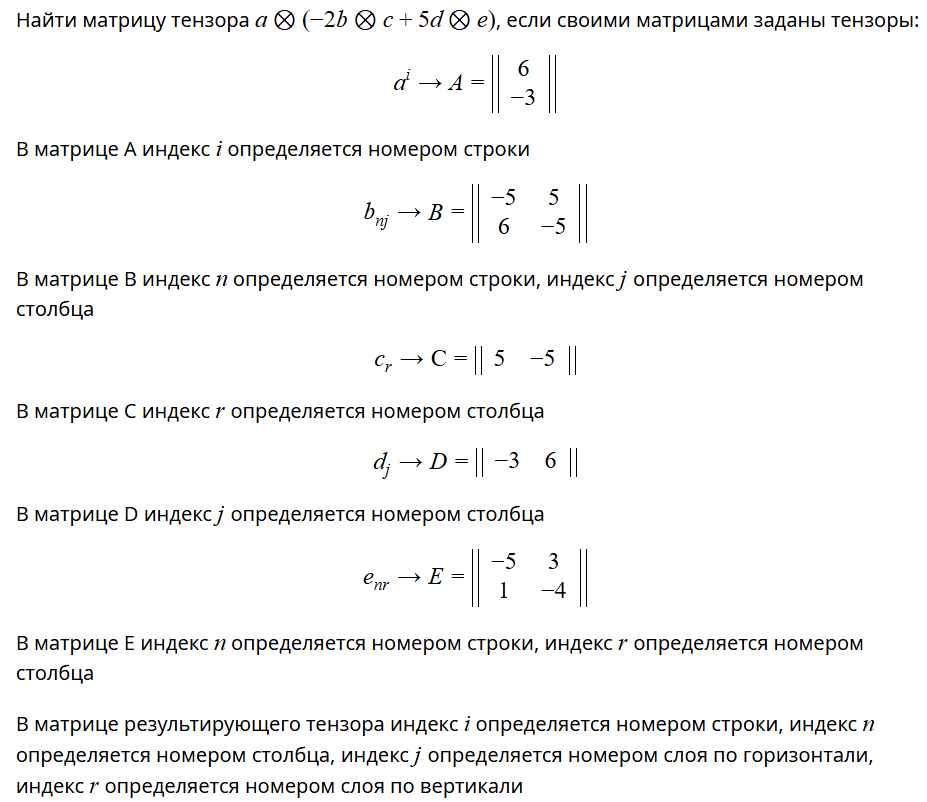

In [31]:
A = Tensor('6 -3', 2, 1, 0)
B = Tensor('-5 6 5 -5', 2, 0, 2)
C = Tensor('5 -5', 2, 0, 1)
D = Tensor('-3 6', 2, 0, 1)
E = Tensor('-5 1 3 -4', 2, 0, 2)
# print(A, B, C, D, E, sep='\n===\n')

R = A @ (((B * -2) @ C) + ((D * 5) @ E))

print(R)

Tensor (3, 1), dim = 2, status = TStatus.EVEN
750 -1260 | -570 900
-375 630 | 285 -450
-390 480 | 660 -1020
195 -240 | -330 510
[750, -1260, -570, 900; -375, 630, 285, -450; -390, 480, 660, -1020; 195, -240, -330, 510]


### Задача 10
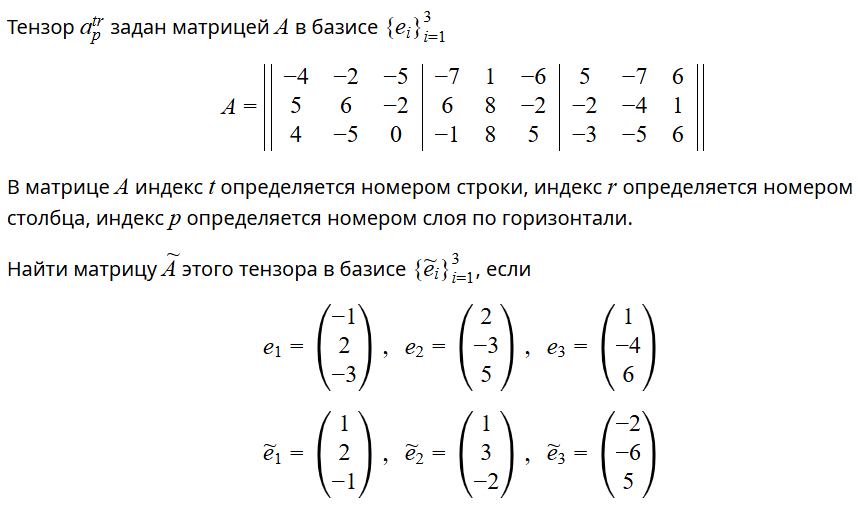

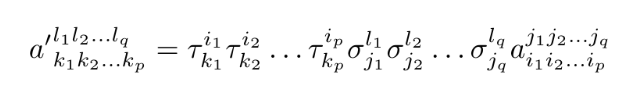

Для моего случая немая сумма будет такая
$\tilde{a}^{tr}_{p} = \tau^{i_1}_p * \sigma^t_{j_1} * \sigma^r_{j_2} * a^{j_1 j_2}_{i_1}$

In [19]:
data = "−4 5 4 ​ −2 6 −5 ​ −5 −2 0 ​ −7 6 −1 ​ 1 8 8 ​ −6 −2 5 ​ 5 −2 −3 ​ −7 −4 −5 ​ 6 1 6 ​ ​​"
a = Tensor(data, 3, 2, 1)
print(a)

e1, e2, e3 = [-1, 2, -3], [2, -3, 5], [1, -4, 6]
old_basis = np.matrix([[e1[0], e2[0], e3[0]], [e1[1], e2[1], e3[1]], [e1[2], e2[2], e3[2]]], float)
e1, e2, e3 = [1, 2, -1], [1, 3, -2], [-2, -6, 5]
new_basis = np.matrix([[e1[0], e2[0], e3[0]], [e1[1], e2[1], e3[1]], [e1[2], e2[2], e3[2]]], float)
# print(old_basis, new_basis, sep='\n')

S = np.linalg.inv(new_basis).dot(old_basis)
T = np.around(np.linalg.inv(S), 12)
T, S = np.asarray(T), np.asarray(S)
print(T, S, sep='\n')

tilde_a = np.zeros((3, 3, 3))
for (t, k, n) in it.product(range(3), repeat=3):
    total = 0
    for (i1, j1, j2) in it.product(range(3), repeat=3):
            total += T[i1, n] * S[t, j1] * S[k, j2] * a[j1, j2, i1]
    tilde_a[t, k, n] = total

tilde_a = np.round(tilde_a, 10).astype(int)
res_tensor = Tensor(tilde_a, 3, 2, 1)
print(res_tensor)

Tensor (1, 2), dim = 3, status = TStatus.HORIZONTAL
-4 -2 -5 | -7 1 -6 | 5 -7 6
5 6 -2 | 6 8 -2 | -2 -4 1
4 -5 0 | -1 8 5 | -3 -5 6
[-4, -2, -5, -7, 1, -6, 5, -7, 6; 5, 6, -2, 6, 8, -2, -2, -4, 1; 4, -5, 0, -1, 8, 5, -3, -5, 6]
[[  7.   9. -13.]
 [  4.   5.  -8.]
 [  0.   0.   1.]]
[[-5.  9.  7.]
 [ 4. -7. -4.]
 [ 0.  0.  1.]]
Tensor (1, 2), dim = 3, status = TStatus.HORIZONTAL
3019 -1897 237 | 3735 -2336 298 | -6050 3847 -446
-2383 1538 -162 | -2973 1914 -204 | 4690 -3038 311
-7 37 20 | -25 59 25 | -39 -24 -34
[3019, -1897, 237, 3735, -2336, 298, -6050, 3847, -446; -2383, 1538, -162, -2973, 1914, -204, 4690, -3038, 311; -7, 37, 20, -25, 59, 25, -39, -24, -34]
